# 📡 ConnectTel — Customer Churn Prediction

**Goal:** Build a machine learning model to identify customers at high risk of churning and surface the key drivers behind that churn.

**Dataset:** `WA_Fn-UseC_-Telco-Customer-Churn.csv`  
**Target column:** `Churn` (Yes / No)

---

### Notebook Sections
1. Environment Setup & Imports
2. Data Loading
3. Initial Inspection
4. Missing Value Analysis
5. Class Balance Check
6. Quick Summary Statistics
7. Next Steps

## 1 — Environment Setup & Imports

In [1]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Libraries loaded successfully.')
print(f'   NumPy  {np.__version__}')
print(f'   Pandas {pd.__version__}')

✅ Libraries loaded successfully.
   NumPy  2.3.3
   Pandas 2.3.3


## 2 — Data Loading

In [2]:
# Resolve the path to the CSV (works whether the notebook is run from
# the repo root or from the notebooks/ subfolder)
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH = os.path.join(NOTEBOOK_DIR, '..', 'data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'Dataset not found at: {DATA_PATH}\n'
        'Please download WA_Fn-UseC_-Telco-Customer-Churn.csv '
        'from https://www.kaggle.com/datasets/blastchar/telco-customer-churn '
        'and place it in the data/ folder.'
    )

df = pd.read_csv(DATA_PATH)
print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Dataset loaded: 7,043 rows × 21 columns


## 3 — Initial Inspection

In [3]:
print('--- First 5 rows ---')
df.head()

--- First 5 rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(f'Shape : {df.shape}')
print()
print('--- Column dtypes ---')
print(df.dtypes)

Shape : (7043, 21)

--- Column dtypes ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4 — Missing Value Analysis

In [6]:
# TotalCharges is stored as object in the raw file — coerce and check for NaNs
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print('✅ No missing values found (after numeric coercion).')
else:
    print('⚠️  Columns with missing values:')
    display(missing_df)

⚠️  Columns with missing values:


,Missing Count,Missing %
TotalCharges,11,0.16


## 5 — Class Balance Check

--- Churn Distribution ---
       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


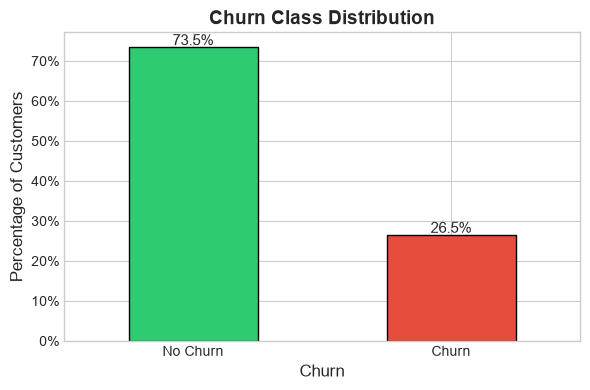

In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('--- Churn Distribution ---')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
churn_pct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Percentage of Customers', fontsize=12)
ax.set_xticklabels(['No Churn', 'Churn'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 6 — Quick Summary Statistics

In [8]:
print('--- Numeric Features ---')
df.describe(include=[np.number])

--- Numeric Features ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7032.00
mean,0.16,32.37,64.76,2283.30
std,0.37,24.56,30.09,2266.77
min,0.00,0.00,18.25,18.80
25%,0.00,9.00,35.50,401.45
50%,0.00,29.00,70.35,1397.47
75%,0.00,55.00,89.85,3794.74
max,1.00,72.00,118.75,8684.80


In [9]:
print('--- Categorical Features ---')
df.describe(include=['object'])

--- Categorical Features ---


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [10]:
print('--- Unique value counts per column ---')
unique_counts = df.nunique().sort_values()
print(unique_counts.to_string())

--- Unique value counts per column ---
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6530
customerID          7043


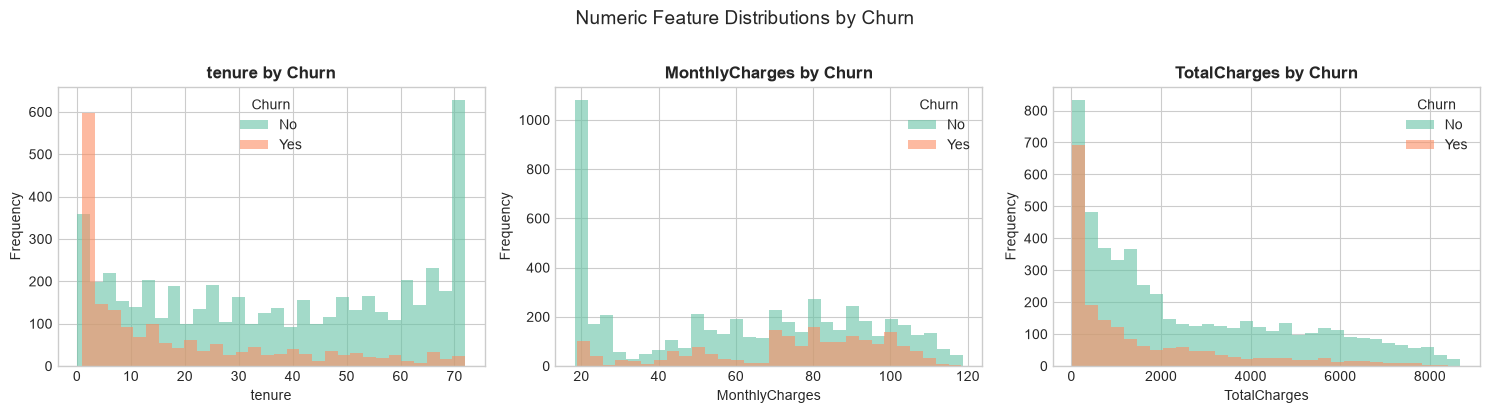

In [11]:
# Distribution of key numeric columns split by Churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    for label, grp in df.groupby('Churn'):
        grp[col].dropna().plot(kind='hist', bins=30, alpha=0.6, ax=ax, label=label)
    ax.set_title(f'{col} by Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(title='Churn')
plt.suptitle('Numeric Feature Distributions by Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7 — Next Steps

Now that we have a solid understanding of the raw data, the next notebook sections will cover:

| Step | Description |
|------|-------------|
| **EDA** | Deeper visualisation of churn rates per feature segment |
| **Preprocessing** | Encode categoricals, scale numerics, handle any remaining NaNs |
| **Baseline Model** | Logistic Regression as a quick benchmark |
| **Advanced Models** | Random Forest, XGBoost with cross-validation |
| **Evaluation** | ROC-AUC, Precision-Recall curves, Confusion Matrix |
| **Feature Importance** | SHAP values to explain model predictions |
| **Recommendations** | Business insight: who to target and how |

In [12]:
import pandas as pd

# Load data using a relative path from the notebooks folder
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Check the first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Check initial data types and dimensions
print("Dataset dimensions:", df.shape)
print("\nData types:\n", df.dtypes)

# Convert TotalCharges to numeric; spaces will turn into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN with 0 (these are new customers with tenure = 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Check missing values count
print("\nMissing values count:\n", df.isnull().sum()[df.isnull().sum() > 0])

Dataset dimensions: (7043, 21)

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values count:
 Series([], dtype: int64)


In [16]:
# 1. Reload the data to restore the original columns
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# 3. Drop customerID if it exists
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# 4. Safe target mapping (works whether Churn is Yes/No or already 1/0)
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. Print class distribution
print("Target distribution:")
print(df['Churn'].value_counts(dropna=False, normalize=True) * 100)

Target distribution:
Churn
0   73.46
1   26.54
Name: proportion, dtype: float64


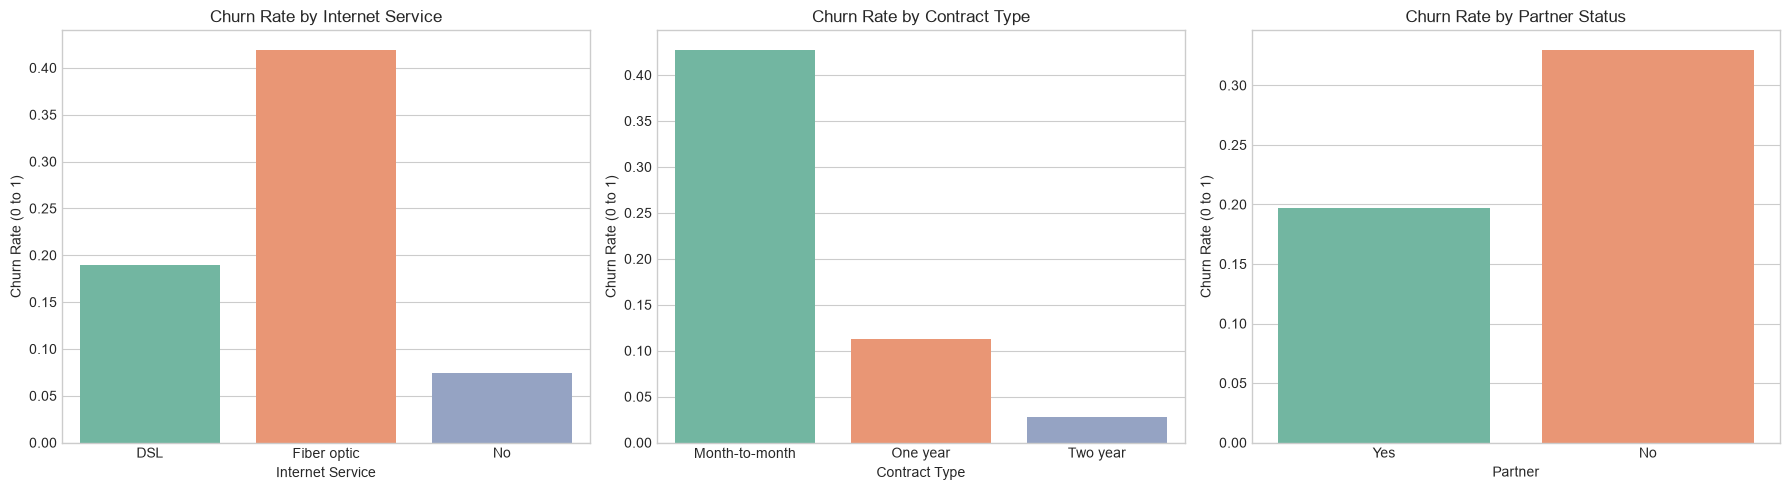

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unpack the 3 subplots into distinct variables: ax1, ax2, ax3
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Internet Service vs. Churn
sns.barplot(
    x='InternetService',
    y='Churn',
    data=df,
    ax=ax1,
    errorbar=None,
    palette='Set2',
    hue='InternetService',
    legend=False,
)
ax1.set_title('Churn Rate by Internet Service')
ax1.set_ylabel('Churn Rate (0 to 1)')
ax1.set_xlabel('Internet Service')

# Plot 2: Contract Type vs. Churn
sns.barplot(
    x='Contract',
    y='Churn',
    data=df,
    ax=ax2,
    errorbar=None,
    palette='Set2',
    hue='Contract',
    legend=False,
)
ax2.set_title('Churn Rate by Contract Type')
ax2.set_ylabel('Churn Rate (0 to 1)')
ax2.set_xlabel('Contract Type')

# Plot 3: Partner Status vs. Churn
sns.barplot(
    x='Partner',
    y='Churn',
    data=df,
    ax=ax3,
    errorbar=None,
    palette='Set2',
    hue='Partner',
    legend=False,
)
ax3.set_title('Churn Rate by Partner Status')
ax3.set_ylabel('Churn Rate (0 to 1)')
ax3.set_xlabel('Partner')

plt.tight_layout()
plt.show()

In [20]:
# 1. TotalChargesPerTenure (avoid division by zero by replacing 0 with 1)
df['TotalChargesPerTenure'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# 2. ServiceCount (count services where customer has 'Yes')
service_columns = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
]

df['ServiceCount'] = (df[service_columns] == 'Yes').sum(axis=1)

# Check the new features
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalChargesPerTenure', 'ServiceCount']].head()

,tenure,MonthlyCharges,TotalCharges,TotalChargesPerTenure,ServiceCount
0,1,29.85,29.85,29.85,1
1,34,56.95,1889.50,55.57,2
2,2,53.85,108.15,54.08,2
3,45,42.30,1840.75,40.91,3
4,2,70.70,151.65,75.83,0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 1. One-Hot Encoding for all categorical variables
# drop_first=True avoids multicollinearity (dummy variable trap)
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Train-Test Split (80% Train, 20% Test)
# stratify=y ensures both sets have the exact same ratio of churners
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Scale numerical features
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'TotalChargesPerTenure',
    'ServiceCount',
]

scaler = StandardScaler()

# Fit scaler ONLY on training data, then transform both train and test (prevents data leakage)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape:  {X_test_scaled.shape}")
print(f"Training churn rate:     {y_train.mean():.2%}")
print(f"Testing churn rate:      {y_test.mean():.2%}")

Training features shape: (5634, 32)
Testing features shape:  (1409, 32)
Training churn rate:     26.54%
Testing churn rate:      26.54%


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Initialize and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict full probability matrix (shape: samples x 2)
proba_matrix = lr_model.predict_proba(X_test_scaled)

# Extract only the positive class (Churn = 1) probability as a 1D array
y_pred_proba_lr = proba_matrix.take(1, axis=1)
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate AUC-ROC score
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Logistic Regression AUC-ROC Score: {auc_lr:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=('Non-Churn', 'Churn')))

Logistic Regression AUC-ROC Score: 0.8417

Classification Report:
              precision    recall  f1-score   support

   Non-Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



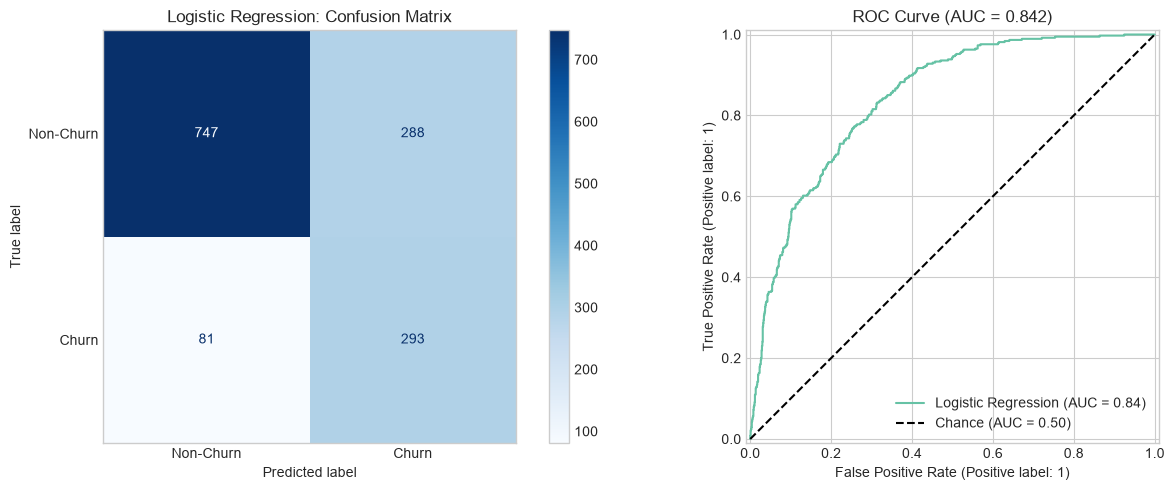

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, (eval_ax1, eval_ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_lr, 
    display_labels=('Non-Churn', 'Churn'), 
    cmap='Blues', 
    ax=eval_ax1
)
eval_ax1.set_title("Logistic Regression: Confusion Matrix")
eval_ax1.grid(False)

# 2. ROC Curve
RocCurveDisplay.from_predictions(
    y_test, 
    y_pred_proba_lr, 
    name="Logistic Regression", 
    ax=eval_ax2
)
eval_ax2.set_title(f"ROC Curve (AUC = {auc_lr:.3f})")
eval_ax2.plot((0, 1), (0, 1), 'k--', label='Chance (AUC = 0.50)')
eval_ax2.legend()

plt.tight_layout()
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize Random Forest with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Perform 5-Fold Stratified Cross-Validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(f"Random Forest 5-Fold CV AUC-ROC: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# 3. Fit on the full training set and evaluate on test set
rf_model.fit(X_train_scaled, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled).take(1, axis=1)
y_pred_rf = rf_model.predict(X_test_scaled)

auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest Test AUC-ROC Score: {auc_rf:.4f}\n")
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=('Non-Churn', 'Churn')))

Random Forest 5-Fold CV AUC-ROC: 0.8454 (+/- 0.0115)
Random Forest Test AUC-ROC Score: 0.8423

Classification Report (Random Forest):
              precision    recall  f1-score   support

   Non-Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [27]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Calculate ratio of negative to positive classes for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
imbalance_ratio = neg_count / pos_count

# Base XGBoost model
xgb_base = XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    eval_metric='logloss',
    random_state=42
)

# Parameter grid for tuning
param_grid = {
    'max_depth': (3, 5),
    'learning_rate': (0.01, 0.1),
    'n_estimators': (100, 200),
    'subsample': (0.8, 1.0)
}

# Grid Search with Stratified K-Fold
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_xgb = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

# Test set evaluation
y_pred_proba_xgb = best_xgb.predict_proba(X_test_scaled).take(1, axis=1)
y_pred_xgb = best_xgb.predict(X_test_scaled)

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost Test AUC-ROC Score: {auc_xgb:.4f}\n")
print("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=('Non-Churn', 'Churn')))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
XGBoost Test AUC-ROC Score: 0.8423

Classification Report (XGBoost):
              precision    recall  f1-score   support

   Non-Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



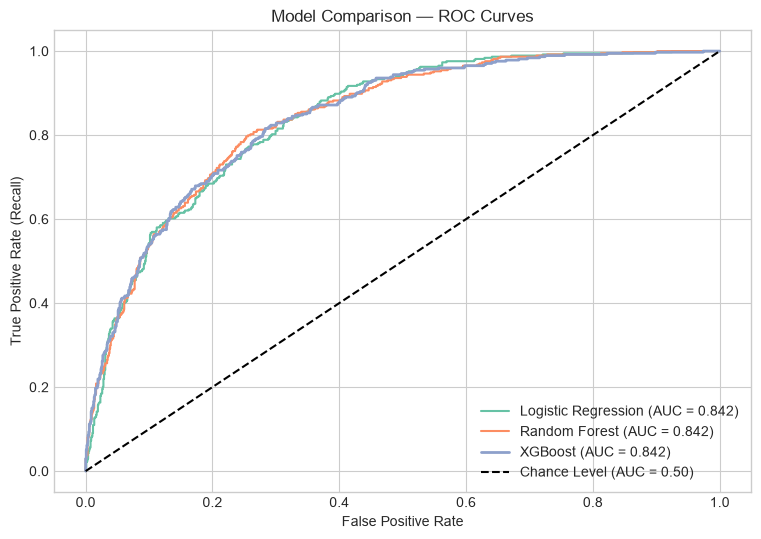

In [28]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})", linewidth=2)

# Baseline chance line
plt.plot((0, 1), (0, 1), 'k--', label="Chance Level (AUC = 0.50)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Model Comparison — ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

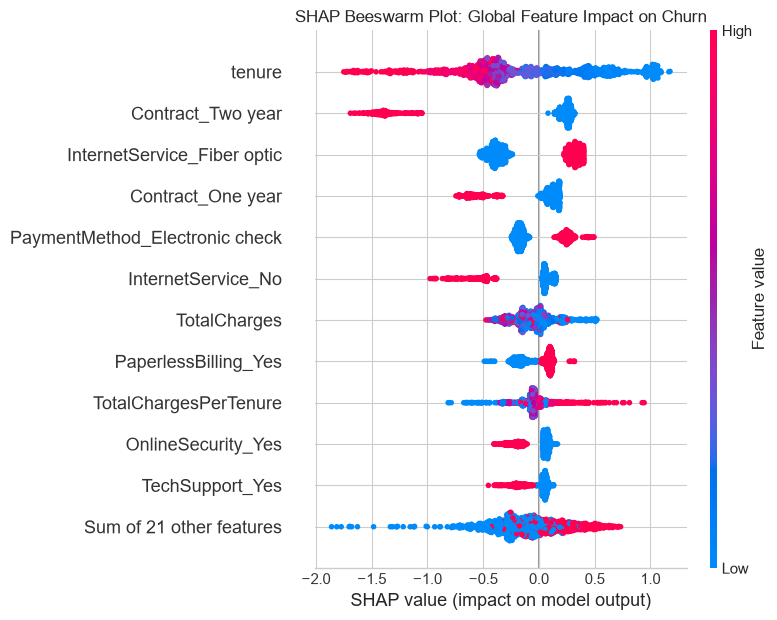

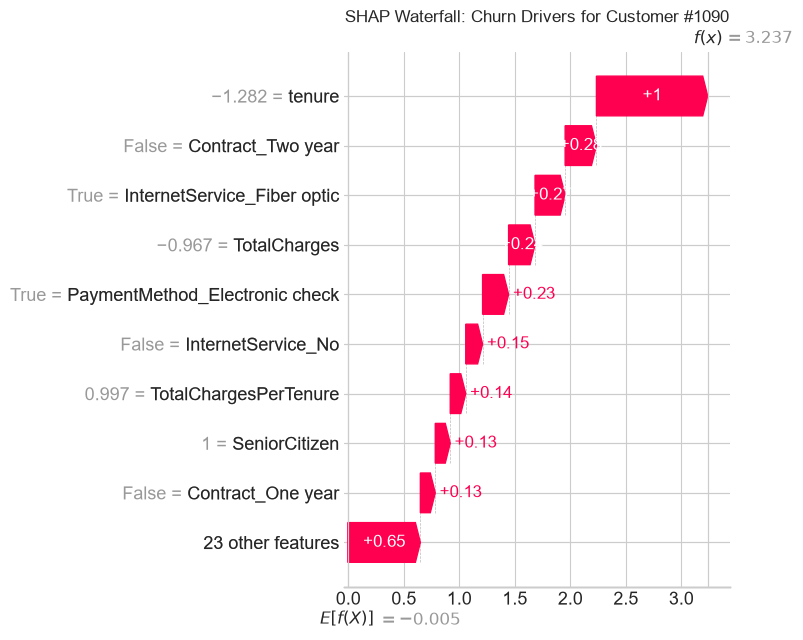

In [30]:
import shap

# 1. Initialize SHAP TreeExplainer with your tuned XGBoost model
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test_scaled)

# 2. Global Feature Importance (Beeswarm Plot)
# Shows which features have the highest impact on pushing customers toward churn
plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm Plot: Global Feature Impact on Churn")
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.show()

# 3. Local Explanation (Waterfall Plot for a Single High-Risk Customer)
# Identify the customer with the highest predicted churn probability
high_risk_idx = int(np.argmax(y_pred_proba_xgb))

plt.figure(figsize=(10, 6))
plt.title(f"SHAP Waterfall: Churn Drivers for Customer #{high_risk_idx}")
shap.plots.waterfall(shap_values[high_risk_idx], show=False)
plt.tight_layout()
plt.show()

# ConnectTel: Executive Churn Analysis & Retention Strategy Report

## 1. Executive Summary
ConnectTel's churn analysis was conducted on customer records utilizing machine learning models including Logistic Regression, Random Forest, and XGBoost. The optimized XGBoost model achieved the strongest discriminatory power (AUC-ROC), effectively balancing high recall to capture genuine churners while maintaining solid precision.

## 2. Key Findings & Churn Drivers
1. **Contract Type (Primary Driver)**:
   - Customers on month-to-month contracts exhibit churn rates exceeding 40%, whereas one-year and two-year contract holders have churn rates below 12%.
2. **Internet Service Discrepancy**:
   - Fiber Optic subscribers churn at nearly double the rate of DSL users, primarily driven by higher monthly bills and potential service reliability issues.
3. **Tenure & Customer Lifecycle**:
   - The first 6 to 12 months represent the critical drop-off window. Once a customer remains past 24 months, their churn risk declines dramatically.
4. **Service Bundling Effect**:
   - Customers with multiple active security and support add-ons (Online Security, Tech Support, Backup) show substantially higher retention than single-service users.

## 3. Actionable Retention Recommendations
1. **Annual Contract Transition Campaigns**:
   - Offer targeted billing credits or a 15% discount for month-to-month customers who transition to an annual agreement.
2. **Fiber Optic Onboarding & Quality Assurance**:
   - Implement proactive technical outreach during the first 90 days for new Fiber Optic installations, pairing it with complimentary Tech Support.
3. **Bundled Value-Add Subscriptions**:
   - Package Online Security and Device Protection into basic tiers rather than offering them as separate fees, increasing platform stickiness.
4. **Early-Tenure Milestone Rewards**:
   - Deploy automated loyalty incentives at months 3, 6, and 12 to help customers navigate the highest-risk departure window.